# Company Hiring Score
### Lloyds BCB 毕设项目 — 公司级招聘评分

**输入**
- `company_enriched.csv`：已合并 `sector_hiring_score` 的公司主表
- 使用字段：`CompanyStatus`, `company_age_years`, `Accounts_AccountCategory`,
  `Accounts_LastMadeUpDate`, `Accounts_NextDueDate`, `ConfStmtLastMadeUpDate`,
  `Mortgages_NumMortCharges`, `Mortgages_NumMortOutstanding`, `Mortgages_NumMortSatisfied`

**输出**
- `company_hiring_score`：进入 `opportunity_score`（权重 0.20）
- 各因子列：供解释和审计

**公式**
```
company_hiring_score = sector_hiring_score
    × status_factor
    × age_factor
    × scale_factor
    × filing_freshness_factor
    × financing_factor
```

**设计原则**
- 每个因子只用一个字段来源，不与 `financial_score` 重叠
- 因子乘积上限 clip 到 1.40，防止极端值
- `DORMANT` / 非 Active 状态直接归零，不影响其他维度分数


## 0. 导入

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

matplotlib.rcParams['figure.dpi'] = 120
print("导入完成")

导入完成


## 1. 配置路径

In [5]:
INPUT_PATH  = Path("../output/adzuna_sector_fullfield_output/companies_with_sector_hiring.csv")
OUTPUT_DIR  = Path("../output/hiring_score")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "company_hiring_score.csv"
print(f"输入: {INPUT_PATH}")
print(f"输出: {OUTPUT_PATH}")

输入: ../output/adzuna_sector_fullfield_output/companies_with_sector_hiring.csv
输出: ../output/hiring_score/company_hiring_score.csv


## 2. 读取数据

In [6]:
df = pd.read_csv(INPUT_PATH, low_memory=False, dtype=str)
print(f"读取：{len(df):,} 行，{len(df.columns)} 列")

# 检查必要字段
required = [
    "CompanyNumber", "CompanyName", "primary_sector",
    "sector_hiring_score", "CompanyStatus", "company_age_years",
    "Accounts_AccountCategory", "Accounts_LastMadeUpDate",
    "Accounts_NextDueDate", "Mortgages_NumMortCharges",
    "Mortgages_NumMortOutstanding", "Mortgages_NumMortSatisfied",
]
missing = [c for c in required if c not in df.columns]
if missing:
    print(f"缺少字段: {missing}")
else:
    print("所有字段均存在")

# ConfStmtLastMadeUpDate 是可选字段
has_conf_stmt = "ConfStmtLastMadeUpDate" in df.columns
print(f"  ConfStmtLastMadeUpDate 字段: {'存在' if has_conf_stmt else '不存在（将跳过）'}")

df["sector_hiring_score"] = pd.to_numeric(df["sector_hiring_score"], errors="coerce")
print(f"\nsector_hiring_score 分布：")
print(df["sector_hiring_score"].describe().round(1).to_string())

读取：3,415,689 行，37 列
所有字段均存在
  ConfStmtLastMadeUpDate 字段: 不存在（将跳过）

sector_hiring_score 分布：
count    3415689.0
mean          54.3
std           19.1
min           20.8
25%           58.0
50%           65.7
75%           66.9
max           72.4


## 3. 因子函数定义

每个因子独立计算，乘积作为对 `sector_hiring_score` 的调节系数。

| 因子 | 字段来源 | 逻辑说明 |
|------|----------|----------|
| `status_factor` | `CompanyStatus` | 非 Active 直接归零 |
| `age_factor` | `company_age_years` | 3–7年扩张期给最高系数 |
| `scale_factor` | `Accounts_AccountCategory` | 按申报完整度而非规模 |
| `filing_freshness_factor` | `Accounts_LastMadeUpDate` + `Accounts_NextDueDate` + `ConfStmtLastMadeUpDate` | 申报时效与逾期检查 |
| `financing_factor` | `Mortgages_NumMortCharges` + `Mortgages_NumMortOutstanding` + `Mortgages_NumMortSatisfied` | 融资历史与当前负债组合判断 |


In [7]:
# ─── Factor 1: Status ────────────────────────────────────────────
# 数据字典：CompanyStatus 有6种值，只有 Active 是目标客群
# Active - Proposal to Strike Off 虽仍注册但即将注销，不作为目标

ACTIVE_STATUSES = {"active"}

def status_factor(status) -> float:
    if pd.isna(status):
        return 0.0
    return 1.0 if str(status).strip().lower() in ACTIVE_STATUSES else 0.0


# ─── Factor 2: Age ───────────────────────────────────────────────
# 文献依据：Churchill & Lewis (1983) 公司生命周期五阶段模型
#   <2年：初创期，招聘需求不稳定
#   2–3年：成长早期
#   3–7年：扩张期，融资和招聘需求最旺盛 → 最高系数
#   7–10年：成熟期
#   >10年：稳定期，需求趋于平稳

def age_factor(age) -> float:
    if pd.isna(age):
        return 0.95   # 缺失时保守处理
    age = float(age)
    if age < 2:
        return 0.65
    elif age < 3:
        return 0.80
    elif age <= 7:
        return 1.15
    elif age <= 10:
        return 1.00
    else:
        return 0.90


# ─── Factor 3: Scale (Account Category) ─────────────────────────
# 数据字典：Accounts_AccountCategory 是申报豁免类型，不是规模
# 按申报完整度打分：完整账目 > 豁免账目 > 未申报 > 休眠
# DORMANT 单独归零，因为休眠公司不是目标客群
#
# 使用精确映射（exact match after normalisation），
# 避免 substring 误判（如 "full" 误匹配含 "full" 的其他值）

SCALE_MAP_EXACT = {
    # ── 直接归零 ──────────────────────────────────────
    "dormant":                       0.0,
    # ── 申报缺失 / 极低完整度 ─────────────────────────
    "no accounts filed":             0.60,
    "accounts type not available":   0.70,
    # ── 豁免类（完整度递增）──────────────────────────
    "micro entity":                  0.85,
    "total exemption full":          0.90,
    "total exemption small":         0.90,
    "unaudited abridged":            0.95,
    "audited abridged":              0.95,
    # ── 标准申报 ──────────────────────────────────────
    "small":                         1.00,
    "small company":                 1.00,
    "medium":                        1.10,
    "medium sized":                  1.10,
    "full":                          1.05,
    "full accounts":                 1.05,
    # ── 集团 / 特殊 ───────────────────────────────────
    "group":                         1.05,
    "group accounts":                1.05,
    "public limited company":        1.00,
    "initial":                       0.85,   # 首次申报，信息有限
}

def scale_factor(category) -> float:
    if pd.isna(category):
        return 0.95
    # 标准化：小写 + 去首尾空格 + 合并多余空格
    c = " ".join(str(category).strip().lower().split())
    if c in SCALE_MAP_EXACT:
        return SCALE_MAP_EXACT[c]
    # 未精确匹配时保守处理（可取消注释下行排查未知类型）
    # print(f"  [scale_factor] unrecognised: '{category}'")
    return 0.95


# ─── Factor 4: Filing Freshness ──────────────────────────────────
# 三重检查：
#   ① Accounts_NextDueDate 是否已逾期（最强信号）
#   ② Accounts_LastMadeUpDate 距今多少天
#   ③ ConfStmtLastMadeUpDate 距今多少天（若有）
# 取最悲观的结果作为最终因子

def filing_freshness_factor(last_accounts, next_due,
                             conf_stmt_last=None) -> float:
    today = pd.Timestamp.today().normalize()

    # ① 逾期检查
    dt_next = pd.to_datetime(next_due, errors="coerce")
    if pd.notna(dt_next) and dt_next.normalize() < today:
        return 0.50   # 已逾期，强烈风险信号

    # ② 财务报表时效
    dt_last = pd.to_datetime(last_accounts, errors="coerce")
    if pd.isna(dt_last):
        score_accounts = 0.85
    else:
        days = (today - dt_last.normalize()).days
        if days <= 365:
            score_accounts = 1.00
        elif days <= 540:
            score_accounts = 0.85
        elif days <= 730:
            score_accounts = 0.70
        else:
            score_accounts = 0.55

    # ③ Confirmation Statement 时效（可选）
    if conf_stmt_last is not None:
        dt_conf = pd.to_datetime(conf_stmt_last, errors="coerce")
        if pd.isna(dt_conf):
            score_conf = 0.90
        else:
            days_conf = (today - dt_conf.normalize()).days
            if days_conf <= 365:
                score_conf = 1.00
            elif days_conf <= 540:
                score_conf = 0.90
            elif days_conf <= 730:
                score_conf = 0.75
            else:
                score_conf = 0.60
        return min(score_accounts, score_conf)   # 取更悲观的

    return score_accounts


# ─── Factor 5: Financing History ─────────────────────────────────
# 数据字典：
#   NumMortCharges     = 历史登记抵押总数
#   NumMortOutstanding = 当前未解除抵押数
#   NumMortSatisfied   = 已完全解除数
#
# 组合逻辑：
#   有融资历史且已还清 → 最理想（有银行关系，风险可控）
#   有少量在途抵押     → 中性偏谨慎
#   在途抵押过多       → 负债压力大，谨慎
#   从未有融资记录     → 中性

def financing_factor(num_charges, num_outstanding,
                     num_satisfied) -> float:
    n_chg = pd.to_numeric(num_charges,     errors="coerce")
    n_out = pd.to_numeric(num_outstanding, errors="coerce")
    n_sat = pd.to_numeric(num_satisfied,   errors="coerce")

    n_chg = 0 if pd.isna(n_chg) else int(n_chg)
    n_out = 0 if pd.isna(n_out) else int(n_out)
    n_sat = 0 if pd.isna(n_sat) else int(n_sat)

    if n_out >= 3:
        return 0.85   # 在途抵押过多，负债压力大
    elif n_out >= 1:
        return 0.95   # 有在途抵押，中性偏谨慎
    elif n_chg >= 1 and n_sat >= 1:
        return 1.08   # 有融资历史且已还清，最理想信号
    elif n_chg >= 1:
        return 1.03   # 有融资历史，尚未完全解除
    else:
        return 1.00   # 无融资记录，中性


print("✓ 5个因子函数定义完成")
print()
print("快速验证：")
print(f"  status_factor('Active')          = {status_factor('Active')}")
print(f"  status_factor('Liquidation')     = {status_factor('Liquidation')}")
print(f"  age_factor(5)                    = {age_factor(5)}")
print(f"  age_factor(15)                   = {age_factor(15)}")
print(f"  scale_factor('DORMANT')          = {scale_factor('DORMANT')}")
print(f"  scale_factor('MICRO ENTITY')     = {scale_factor('MICRO ENTITY')}")
print(f"  scale_factor('FULL')             = {scale_factor('FULL')}")
print(f"  scale_factor('Total Exemption Full') = {scale_factor('Total Exemption Full')}")
print(f"  scale_factor('Unknown Category') = {scale_factor('Unknown Category')}")
print(f"  financing_factor(3, 0, 3)        = {financing_factor(3, 0, 3)}")
print(f"  financing_factor(0, 4, 0)        = {financing_factor(0, 4, 0)}")

✓ 5个因子函数定义完成

快速验证：
  status_factor('Active')          = 1.0
  status_factor('Liquidation')     = 0.0
  age_factor(5)                    = 1.15
  age_factor(15)                   = 0.9
  scale_factor('DORMANT')          = 0.0
  scale_factor('MICRO ENTITY')     = 0.85
  scale_factor('FULL')             = 1.05
  scale_factor('Total Exemption Full') = 0.9
  scale_factor('Unknown Category') = 0.95
  financing_factor(3, 0, 3)        = 1.08
  financing_factor(0, 4, 0)        = 0.85


## 4. 计算各因子列

In [8]:
out = df.copy()

# ── status_factor ────────────────────────────────────────────────
out["status_factor"] = out["CompanyStatus"].apply(status_factor)

# ── age_factor ───────────────────────────────────────────────────
out["age_factor"] = pd.to_numeric(
    out["company_age_years"], errors="coerce"
).apply(age_factor)

# ── scale_factor ─────────────────────────────────────────────────
out["scale_factor"] = out["Accounts_AccountCategory"].apply(scale_factor)

# ── filing_freshness_factor ──────────────────────────────────────
conf_col = "ConfStmtLastMadeUpDate" if has_conf_stmt else None

out["filing_freshness_factor"] = out.apply(
    lambda r: filing_freshness_factor(
        r.get("Accounts_LastMadeUpDate"),
        r.get("Accounts_NextDueDate"),
        r.get(conf_col) if conf_col else None,
    ),
    axis=1,
)

# ── financing_factor ─────────────────────────────────────────────
out["financing_factor"] = out.apply(
    lambda r: financing_factor(
        r.get("Mortgages_NumMortCharges"),
        r.get("Mortgages_NumMortOutstanding"),
        r.get("Mortgages_NumMortSatisfied"),
    ),
    axis=1,
)

factor_cols = [
    "status_factor", "age_factor", "scale_factor",
    "filing_freshness_factor", "financing_factor",
]

print("各因子分布：")
print(out[factor_cols].describe().round(3).to_string())

各因子分布：
       status_factor   age_factor  scale_factor  filing_freshness_factor  financing_factor
count    3415689.000  3415689.000   3415689.000              3415689.000       3415689.000
mean           0.923        0.898         0.711                    0.832             0.992
std            0.267        0.180         0.286                    0.129             0.035
min            0.000        0.650         0.000                    0.500             0.850
25%            1.000        0.650         0.600                    0.850             1.000
50%            1.000        0.900         0.850                    0.850             1.000
75%            1.000        1.000         0.900                    0.850             1.000
max            1.000        1.150         1.100                    1.000             1.080


## 5. 计算 `company_hiring_score`

In [9]:
# 乘积因子（去掉 status_factor，status=0 时直接归零）
out["adjustment_factor"] = (
    out["age_factor"]
    * out["scale_factor"]
    * out["filing_freshness_factor"]
    * out["financing_factor"]
)

# clip 到 [0, 1.40]，防止极端值
out["adjustment_factor"] = out["adjustment_factor"].clip(0.0, 1.40)

# status=0 时整体归零
out["company_hiring_score"] = (
    out["sector_hiring_score"]
    * out["adjustment_factor"]
    * out["status_factor"]
).round(1)

# 缺失的 sector_hiring_score 填 0
out["company_hiring_score"] = out["company_hiring_score"].fillna(0)

print(f"company_hiring_score 分布：")
print(out["company_hiring_score"].describe().round(1).to_string())
print()
print(f"归零公司数（status=0 或 dormant）: "
      f"{(out['company_hiring_score'] == 0).sum():,}")

company_hiring_score 分布：
count    3415689.0
mean          27.2
std           20.1
min            0.0
25%           11.5
50%           22.2
75%           44.7
max           98.9

归零公司数（status=0 或 dormant）: 619,614


## 6. 结果预览

In [10]:
preview_cols = [
    "CompanyNumber", "CompanyName", "primary_sector",
    "sector_hiring_score",
    "status_factor", "age_factor", "scale_factor",
    "filing_freshness_factor", "financing_factor",
    "adjustment_factor",
    "company_hiring_score",
]

print("Top 20（按 company_hiring_score 降序）：")
out[preview_cols].sort_values(
    "company_hiring_score", ascending=False
).head(20).reset_index(drop=True)

Top 20（按 company_hiring_score 降序）：


,CompanyNumber,CompanyName,primary_sector,sector_hiring_score,status_factor,age_factor,scale_factor,filing_freshness_factor,financing_factor,adjustment_factor,company_hiring_score
0,12713702,ARIYA NEURO CARE (RESIDENTIAL) LIMITED,Healthcare,72.4,1.0,1.15,1.10,1.0,1.08,1.3662,98.9
1,14964611,ST DAVID'S (1918) CHARITABLE TRUST,Healthcare,72.4,1.0,1.15,1.05,1.0,1.08,1.3041,94.4
2,14949957,SKYRAL DEFENCE LIMITED,"Public sector, education & charities",68.7,1.0,1.15,1.10,1.0,1.08,1.3662,93.9
3,12535808,SKIN + ME LTD,Healthcare,72.4,1.0,1.15,1.10,1.0,1.00,1.2650,91.6
4,12616585,VOI TECHNOLOGY UK LTD,"Technology, legal & professional",66.9,1.0,1.15,1.10,1.0,1.08,1.3662,91.4
5,12384812,EXPENSEMATE LTD,Fast growth & emerging sector,66.7,1.0,1.15,1.10,1.0,1.08,1.3662,91.1
6,12497240,HANDSALE PRIESTY FIELDS LIMITED,Healthcare,72.4,1.0,1.15,1.00,1.0,1.08,1.2420,89.9
7,12085139,LOUGHBOROUGH UNIVERSITY NURSERY LIMITED,Healthcare,72.4,1.0,1.15,1.05,1.0,1.00,1.2075,87.4
8,13739688,FILL FUNCTION UK LIMITED,Healthcare,72.4,1.0,1.15,1.05,1.0,1.00,1.2075,87.4
9,12436438,THE JEAN LANNING FOUNDATION,Healthcare,72.4,1.0,1.15,1.05,1.0,1.00,1.2075,87.4


## 7. 可视化

/var/folders/bs/fv2zw8q92b53tbz4z0w21h700000gn/T/ipykernel_9016/3127019127.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,2].boxplot(sector_groups, labels=sector_labels,


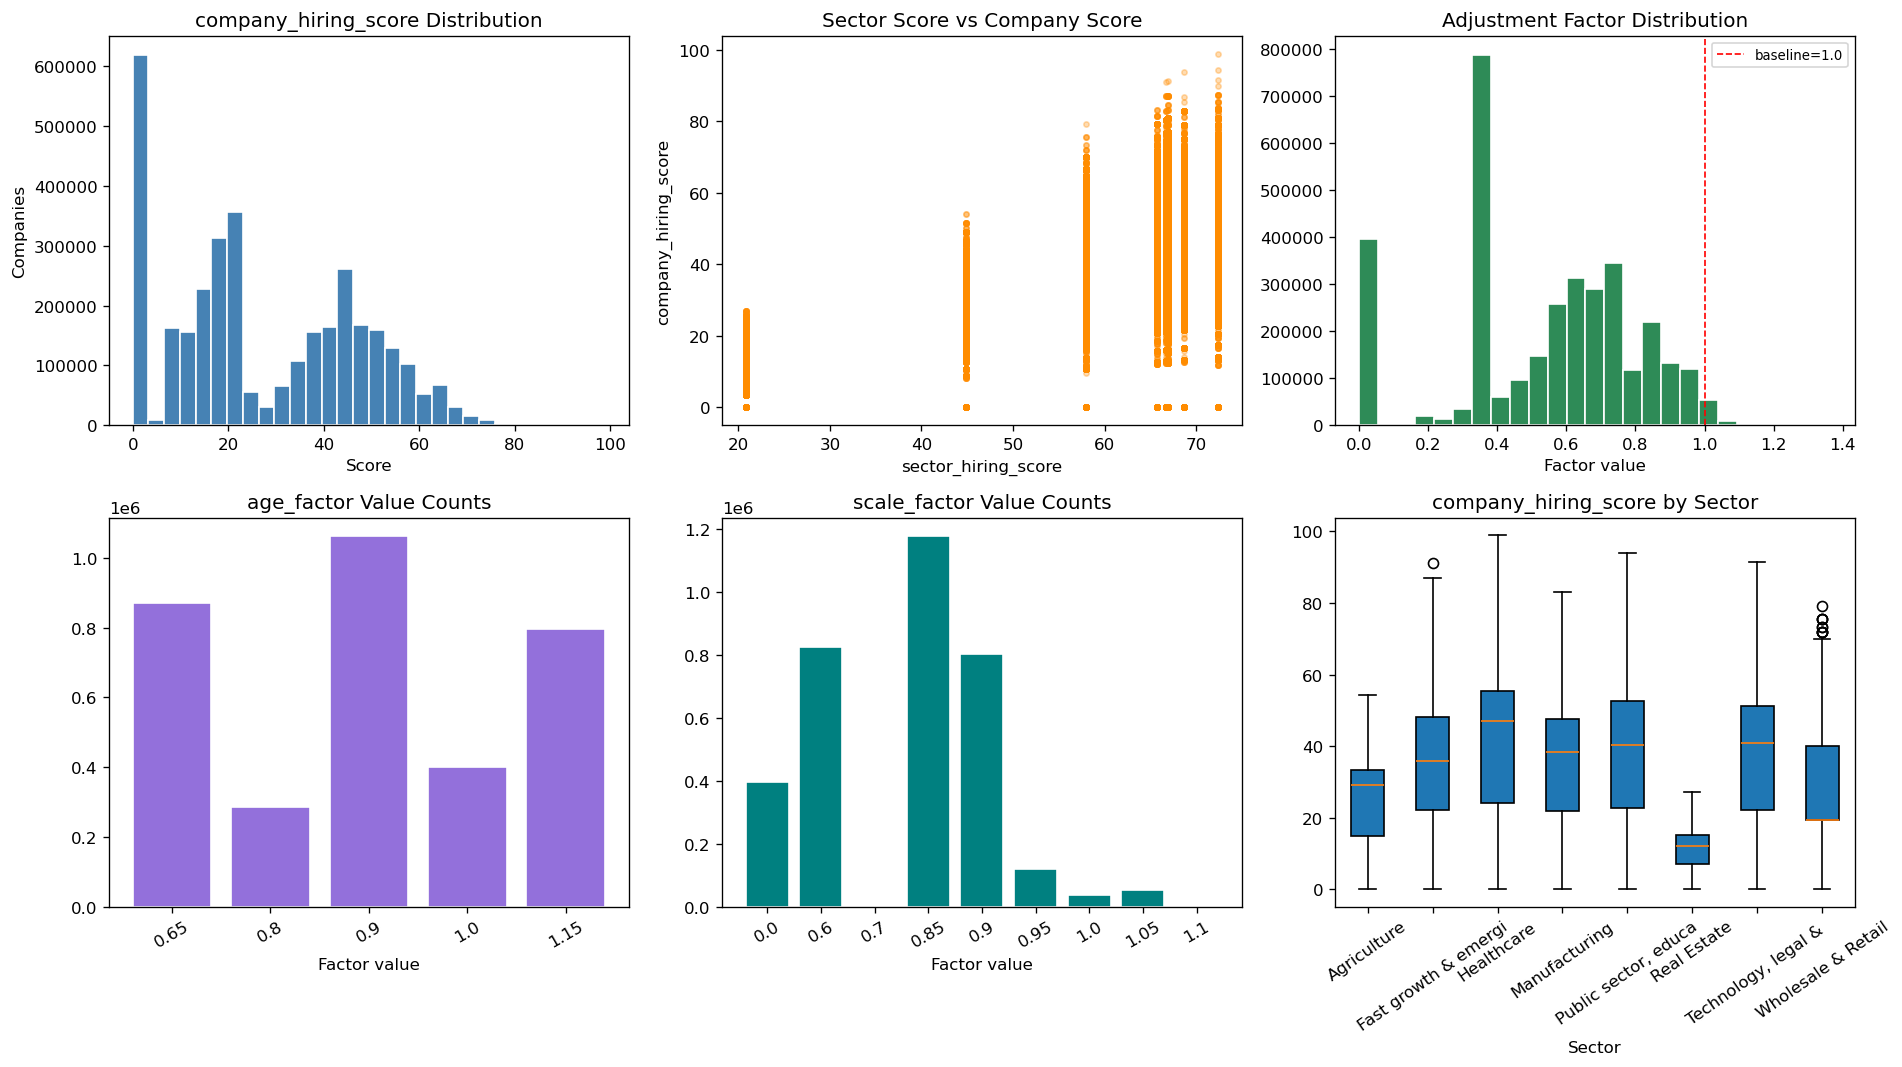

✓ 图表已保存 → ../output/hiring_score/company_hiring_score_viz.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ① company_hiring_score 分布
axes[0,0].hist(
    out["company_hiring_score"].dropna(),
    bins=30, color="steelblue", edgecolor="white"
)
axes[0,0].set_title("company_hiring_score Distribution")
axes[0,0].set_xlabel("Score")
axes[0,0].set_ylabel("Companies")

# ② sector vs company score 对比（散点）
axes[0,1].scatter(
    out["sector_hiring_score"],
    out["company_hiring_score"],
    alpha=0.3, s=10, color="darkorange"
)
axes[0,1].set_title("Sector Score vs Company Score")
axes[0,1].set_xlabel("sector_hiring_score")
axes[0,1].set_ylabel("company_hiring_score")

# ③ adjustment_factor 分布
axes[0,2].hist(
    out["adjustment_factor"].dropna(),
    bins=25, color="seagreen", edgecolor="white"
)
axes[0,2].axvline(1.0, color="red", linestyle="--", linewidth=1, label="baseline=1.0")
axes[0,2].set_title("Adjustment Factor Distribution")
axes[0,2].set_xlabel("Factor value")
axes[0,2].legend(fontsize=8)

# ④ age_factor 分布
age_vc = out["age_factor"].value_counts().sort_index()
axes[1,0].bar(age_vc.index.astype(str), age_vc.values,
              color="mediumpurple", edgecolor="white")
axes[1,0].set_title("age_factor Value Counts")
axes[1,0].set_xlabel("Factor value")
axes[1,0].tick_params(axis="x", rotation=30)

# ⑤ scale_factor 分布
scale_vc = out["scale_factor"].value_counts().sort_index()
axes[1,1].bar(scale_vc.index.astype(str), scale_vc.values,
              color="teal", edgecolor="white")
axes[1,1].set_title("scale_factor Value Counts")
axes[1,1].set_xlabel("Factor value")
axes[1,1].tick_params(axis="x", rotation=30)

# ⑥ 各行业 company_hiring_score 箱线图
# 使用同一个 groupby 迭代确保 groups 与 labels 顺序完全一致
sector_iter   = list(out.groupby("primary_sector", sort=True))
sector_groups = [grp["company_hiring_score"].dropna().values for _, grp in sector_iter]
sector_labels = [s[:20] for s, _ in sector_iter]
axes[1,2].boxplot(sector_groups, labels=sector_labels,
                  patch_artist=True)
axes[1,2].set_title("company_hiring_score by Sector")
axes[1,2].set_xlabel("Sector")
axes[1,2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "company_hiring_score_viz.png",
            bbox_inches="tight", dpi=120)
plt.show()
print(f"✓ 图表已保存 → {OUTPUT_DIR / 'company_hiring_score_viz.png'}")

## 8. 因子贡献分析

展示每个因子对最终得分的实际影响方向和幅度，用于报告和答辩说明。


In [12]:
# 各因子均值（>1 = 整体提升，<1 = 整体折扣）
active_only = out[out["status_factor"] == 1.0]

factor_means = active_only[factor_cols[1:]].mean()  # 排除 status_factor
print("各因子均值（Active公司，>1=提升，<1=折扣）：")
for col, val in factor_means.items():
    direction = "↑ 提升" if val > 1.0 else "↓ 折扣" if val < 1.0 else "→ 中性"
    print(f"  {col:<30} {val:.3f}  {direction}")

print()

# 分行业展示 adjustment_factor 均值
print("各行业平均 adjustment_factor：")
print(
    active_only.groupby("primary_sector")["adjustment_factor"]
    .mean().round(3).sort_values(ascending=False).to_string()
)

各因子均值（Active公司，>1=提升，<1=折扣）：
  age_factor                     0.895  ↓ 折扣
  scale_factor                   0.714  ↓ 折扣
  filing_freshness_factor        0.848  ↓ 折扣
  financing_factor               0.991  ↓ 折扣

各行业平均 adjustment_factor：
primary_sector
Agriculture                             0.598
Healthcare                              0.594
Public sector, education & charities    0.566
Technology, legal & professional        0.562
Manufacturing                           0.556
Fast growth & emerging sector           0.529
Real Estate                             0.525
Wholesale & Retail                      0.516


## 9. 保存输出

In [13]:
output_cols = [
    "CompanyNumber", "CompanyName", "primary_sector",
    "CompanyStatus", "company_age_years",
    "Accounts_AccountCategory",
    "sector_hiring_score",
    "status_factor", "age_factor", "scale_factor",
    "filing_freshness_factor", "financing_factor",
    "adjustment_factor",
    "company_hiring_score",
]

# 加入 hiring_signal_quality（若存在）
if "hiring_signal_quality" in out.columns:
    output_cols.append("hiring_signal_quality")

out[output_cols].to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print(f"✓ 已保存 → {OUTPUT_PATH}")
print(f"  行数: {len(out):,}")
print()
print("字段说明：")
print("  company_hiring_score   → 进入 opportunity_score，权重 0.20")
print("  hiring_signal_quality  → 附属质量指标，不进总分（若存在）")
print("  adjustment_factor      → 5个因子乘积，供审计和解释用")
print()
print("下一步：")
print("  opportunity_score = (")
print("      0.50 * financial_score")
print("    + 0.30 * news_score")
print("    + 0.20 * company_hiring_score  ← 本文件输出")
print("  )")

✓ 已保存 → ../output/hiring_score/company_hiring_score.csv
  行数: 3,415,689

字段说明：
  company_hiring_score   → 进入 opportunity_score，权重 0.20
  hiring_signal_quality  → 附属质量指标，不进总分（若存在）
  adjustment_factor      → 5个因子乘积，供审计和解释用

下一步：
  opportunity_score = (
      0.50 * financial_score
    + 0.30 * news_score
    + 0.20 * company_hiring_score  ← 本文件输出
  )


## 10. 方法说明（供报告引用）

### 公式

```
company_hiring_score = sector_hiring_score × adjustment_factor
adjustment_factor    = age_factor × scale_factor
                     × filing_freshness_factor × financing_factor
                     × status_factor
```

### 各因子文献/逻辑依据

| 因子 | 依据 |
|------|------|
| `status_factor` | 非 Active 公司不在 Lloyds BCB 目标客群范围内（会议纪要） |
| `age_factor` | Churchill & Lewis (1983) 公司生命周期模型，3–7年扩张期融资需求最旺盛 |
| `scale_factor` | Companies House 数据字典：AccountCategory 反映申报完整度，完整账目信息透明度更高 |
| `filing_freshness_factor` | PRA SS1/23：数据质量与时效是模型可靠性的基础要求 |
| `financing_factor` | 已还清融资记录说明公司有银行合作经验（bankability signal） |

### 为什么不把 noise_score 折扣进主分

`hiring_signal_quality`（来自 Adzuna noise_score）衡量的是外部数据源质量，
与公司本身的银行服务需求没有实证相关性。将其直接折扣进主分会引入未经验证的偏差，
且在 FCA Consumer Duty 可解释性要求下无法向监管机构解释。
因此 noise 作为附属质量字段单独输出，不影响 `company_hiring_score`。

> *The hiring score captures sector-level labour demand adjusted for
> company-level characteristics, while the noise score is reported
> separately as a data quality indicator rather than directly
> penalizing the core business signal.*
